Loaded 2271061 rows from 5 files (XRPUSDT).
Shapes — Train: (205886, 10) Test: (16723, 10)

Using scale_pos_weight: 1.05
Starting hyperparameter tuning for 10-minute target...
Fitting 3 folds for each of 12 candidates, totalling 36 fits
[LightGBM] [Info] Number of positive: 100642, number of negative: 105244
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.007870 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2071
[LightGBM] [Info] Number of data points in the train set: 205886, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.488824 -> initscore=-0.044712
[LightGBM] [Info] Start training from score -0.044712

Best parameters found by GridSearchCV:
{'learning_rate': 0.01, 'n_estimators': 200, 'num_leaves': 20}

--- Classification Report (Tuned 10min Model) ---
              precision    recall  f1-score   support

           0       0.52      0.45      0.49      8401
   

<Figure size 800x600 with 0 Axes>

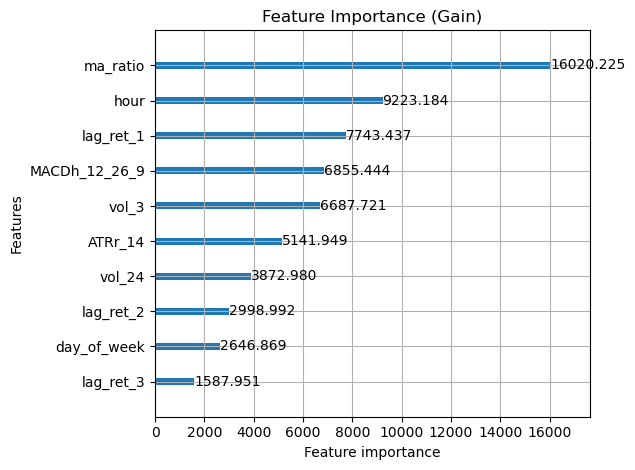

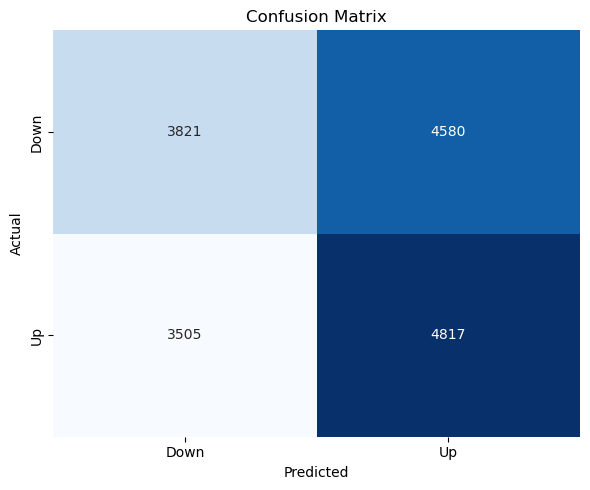

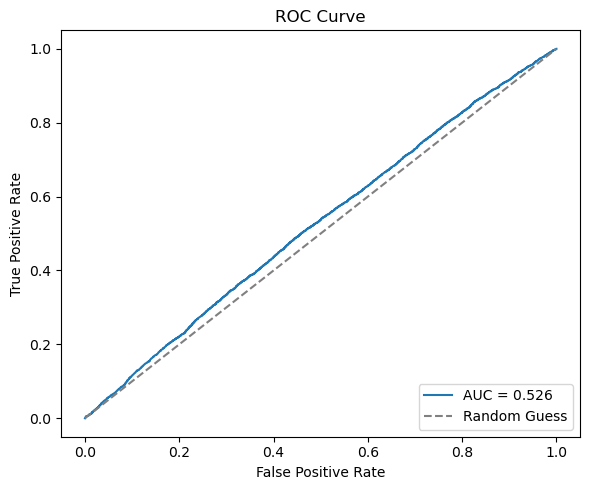

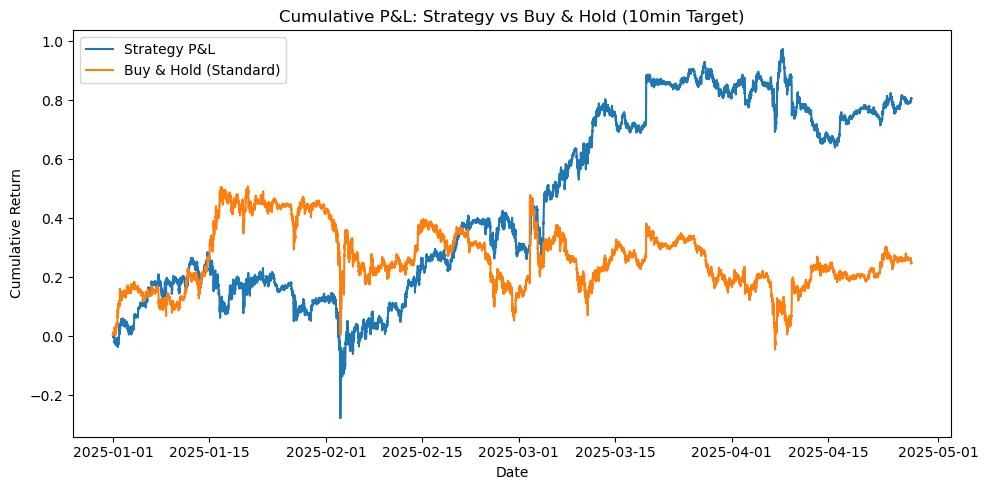

In [20]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.model_selection import GridSearchCV
from datetime import datetime
import pytz
import glob
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas_ta as ta

def load_ohlcv(root_path: str, coin: str = None) -> pd.DataFrame:
    """
    Load all parquet files under root_path (organized by coin_id and year),
    add a 'coin_id' column, parse timestamps (UTC), sort, and optionally filter.
    """
    coin_pattern = f"coin_id={coin}" if coin else "coin_id=*"
    pattern      = os.path.join(root_path, coin_pattern, "year=*", "*.parquet")
    files = glob.glob(pattern, recursive=True)
    if not files: raise FileNotFoundError(f"No files found with pattern: {pattern}")
    
    parts = []
    for fp in files:
        coin_seg     = next(seg for seg in fp.split(os.sep) if seg.startswith("coin_id="))
        this_coin    = coin_seg.split("=", 1)[1]
        df_piece     = pd.read_parquet(fp)
        df_piece['coin_id'] = this_coin
        parts.append(df_piece)
        
    df = pd.concat(parts, ignore_index=True)
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    if df['timestamp'].dt.tz is None:
        df['timestamp'] = df['timestamp'].dt.tz_localize('UTC')
    
    df.sort_values(['coin_id','timestamp'], inplace=True)
    df.reset_index(drop=True, inplace=True)
    if coin:
        df = df[df['coin_id'] == coin].reset_index(drop=True)
    
    print(f"Loaded {len(df)} rows from {len(files)} files ({coin or 'all coins'}).")
    return df

def create_advanced_features(df):
    """
    Creates a rich set of features including advanced technical indicators.
    """
    if 'return' not in df.columns:
        df['return'] = df['close'].pct_change()

    # --- Basic Momentum & Volatility ---
    df['lag_ret_1'] = df['return'].shift(1)
    df['lag_ret_2'] = df['return'].shift(2)
    df['lag_ret_3'] = df['return'].shift(3)
    df['vol_3']     = df['return'].rolling(window=3).std()
    df['vol_24']    = df['return'].rolling(window=24).std()

    # --- Trend Features ---
    df['sma_7'] = df['close'].rolling(window=7).mean()
    df['sma_30'] = df['close'].rolling(window=30).mean()
    df['ma_ratio'] = df['sma_7'] / df['sma_30']
    
    # --- Advanced Technical Indicators ---
    df.ta.macd(close='close', fast=12, slow=26, signal=9, append=True)
    df.ta.atr(high='high', low='low', close='close', length=14, append=True)

    # --- Time-Based Features ---
    df['hour'] = df.index.hour
    df['day_of_week'] = df.index.dayofweek
    
    # Shift all price-derived features to ensure no leakage
    feature_cols = [
        'lag_ret_1', 'lag_ret_2', 'lag_ret_3', 'vol_3', 'vol_24', 'ma_ratio',
        'MACDh_12_26_9', 'ATRr_14'
    ]
    for col in feature_cols:
        df[col] = df[col].shift(1)
            
    return df

 
# 1. Load Data
df_min = load_ohlcv("OHLCV_ffill.parquet", coin="XRPUSDT")
df_min.set_index('timestamp', inplace=True)

# --- KEY CHANGE HERE ---
# 2. Resample to 10-minute bars
df_10m = (
    df_min[['open','high','low','close','volume']]
    .resample('10T') # Changed from '30T' to '10T'
    .agg({'open':'first', 'high':'max', 'low':'min', 'close':'last', 'volume':'sum'})
    .dropna()
)

# 3. Create Features (on the new 10-minute DataFrame)
df_featured = create_advanced_features(df_10m.copy())
df_featured['target'] = (df_featured['return'].shift(-1) > 0).astype(int)
df_featured.dropna(inplace=True)

# 4. Train / Validation / Test split (dates remain the same)
utc = pytz.UTC
val_start  = utc.localize(datetime(2024,12,1,0,0))
val_end    = utc.localize(datetime(2024,12,31,23,59))
test_start = utc.localize(datetime(2025,1,1,0,0))
test_end   = utc.localize(datetime(2025,4,29,23,59))

train = df_featured[df_featured.index < val_start]
val   = df_featured[(df_featured.index >= val_start) & (df_featured.index <= val_end)]
test  = df_featured[(df_featured.index >= test_start) & (df_featured.index <= test_end)]

if train.empty or test.empty: raise ValueError("Train or test split is empty.")

features = [
    'lag_ret_1', 'lag_ret_2', 'lag_ret_3', 'vol_3', 'vol_24', 'ma_ratio',
    'hour', 'day_of_week', 'MACDh_12_26_9', 'ATRr_14'
]
X_train, y_train = train[features], train['target']
X_test,  y_test  =  test[features],  test['target']

print("Shapes — Train:", X_train.shape, "Test:", X_test.shape)

# 5. Hyperparameter Tuning
param_grid = {'learning_rate': [0.01, 0.05], 'num_leaves': [20, 31, 40], 'n_estimators': [100, 200]}
neg_count = y_train.value_counts().get(0, 0)
pos_count = y_train.value_counts().get(1, 0)
scale_pos_weight_value = neg_count / pos_count if pos_count > 0 else 1
print(f"\nUsing scale_pos_weight: {scale_pos_weight_value:.2f}")

base_clf = lgb.LGBMClassifier(objective='binary', random_state=42, scale_pos_weight=scale_pos_weight_value)
grid_search = GridSearchCV(estimator=base_clf, param_grid=param_grid, scoring='roc_auc', cv=3, n_jobs=-1, verbose=1)

print("Starting hyperparameter tuning for 10-minute target...")
grid_search.fit(X_train, y_train)

print("\nBest parameters found by GridSearchCV:")
print(grid_search.best_params_)
best_clf = grid_search.best_estimator_

# 6. Evaluate on Test Set
y_pred = best_clf.predict(X_test)
probs  = best_clf.predict_proba(X_test)[:,1]

print("\n--- Classification Report (Tuned 10min Model) ---")
print(classification_report(y_test, y_pred))

# 7. Visualization Suite
plt.figure(figsize=(8, 6))
lgb.plot_importance(best_clf, importance_type='gain', max_num_features=10, title='Feature Importance (Gain)')
plt.tight_layout(), 
plt.savefig("feature.pdf")

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Down','Up'], yticklabels=['Down','Up'], cbar=False)
plt.xlabel('Predicted'), plt.ylabel('Actual'), plt.title('Confusion Matrix')
plt.tight_layout(), 
plt.savefig("confusion.pdf")

fpr, tpr, _ = roc_curve(y_test, probs)
roc_auc     = auc(fpr, tpr)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
plt.plot([0,1],[0,1], linestyle='--', color='gray', label='Random Guess')
plt.xlabel('False Positive Rate'), plt.ylabel('True Positive Rate')
plt.title('ROC Curve'), plt.legend(loc='lower right')
plt.tight_layout(), 
plt.savefig("roc.pdf")

pnl_df = pd.DataFrame(index=X_test.index)
pnl_df['bh_return'] = df_featured['return'].loc[X_test.index]
pnl_df['signal'] = y_pred * 2 - 1
pnl_df['strat_return'] = pnl_df['signal'] * pnl_df['bh_return'].shift(-1)
pnl_df['cum_bh'] = pnl_df['bh_return'].cumsum()
pnl_df['cum_strat'] = pnl_df['strat_return'].cumsum()

plt.figure(figsize=(10,5))
plt.plot(pnl_df['cum_strat'], label='Strategy P&L')
plt.plot(pnl_df['cum_bh'], label='Buy & Hold (Standard)')
plt.xlabel('Date'), plt.ylabel('Cumulative Return')
plt.title('Cumulative P&L: Strategy vs Buy & Hold (10min Target)')
plt.legend(), plt.tight_layout(), 
plt.savefig("return.pdf")

In [21]:
 

CONFIG = {
    'initial_capital': 10000.0,
    'commission_rate': 0.0000,       # 0.1% trading fee 0.001
    'slippage_factor': 0,      # 0.05% slippage 0.0005
    'data_frequency': '1H',         # Can be '1H', '4H', '1D', etc.
    'risk_free_rate': 0.0,
    'strategy_params': {
        'long_short': {
            'buy_threshold': 0.5,
            'sell_threshold': 0.5
        },
        'trend_following': {
            'sma_window': 200       # The lookback period for the long-term SMA that defines the trend. A common value is 50, 100, or 200.
        },
        'mean_reversion': {
            'bb_window': 20,        # Lookback window for Bollinger Bands
            'bb_std_dev': 2.0       # Number of standard deviations
        }
    }
}



# --- Strategy Signal Generation ---
# --- 1. Mean Reversion Strategy (with Bollinger Bands/ No need for prediction) ---
def generate_mean_reversion_positions(data):
    """
    Generates positions for a Mean Reversion strategy using Bollinger Bands®.

    This strategy operates independently of a prediction model. It sells when
    the price touches the upper band and buys when it touches the lower band,
    assuming the price will revert to the mean.

    Args:
        data (pd.DataFrame): DataFrame with at least a 'close' column.
    Returns:
        pd.Series: A Series of trading positions.
    """
    window = CONFIG['strategy_params']['mean_reversion']['bb_window']
    num_std_dev = CONFIG['strategy_params']['mean_reversion']['bb_std_dev']
    # 1. Calculate the three Bollinger Bands®.
    middle_band = data['close'].rolling(window=window).mean()           # Middle Band: A simple moving average.
    std_dev = data['close'].rolling(window=window).std()
    upper_band = middle_band + (std_dev * num_std_dev)
    lower_band = middle_band - (std_dev * num_std_dev)

    # 2. Initialize positions with zeros.
    positions = pd.Series(index=data.index, data=0, name='position')
    
    # 3. Generate signals based on price crossing the bands.
    # Note: We compare today's price with yesterday's band to avoid lookahead bias.
    # Go Long (+1) if the price crosses BELOW the lower band.
    positions[data['close'] < lower_band] = 1
    # Go Short (-1) if the price crosses ABOVE the upper band.
    positions[data['close'] > upper_band] = -1

    # 4. Generate exit signals: Close the position when the price crosses the middle band.
    # If we are long and price goes above middle, or if we are short and price goes below, exit.
    # To implement this simply, we can use a forward-fill approach.
    # However, a simpler model for backtesting is to hold for a fixed number of periods
    # or until the price crosses the middle band. For simplicity here, we will hold
    # the position until an opposing signal is generated. A more complex exit logic
    # would involve tracking the state (e.g., are we currently in a long trade?).
    # Let's refine the exit logic for clarity:

    # Create a consolidated signal series (1 for buy, -1 for sell, 0 for hold)
    signals = pd.Series(index=data.index, data=0, name='signal')
    signals[data['close'] < lower_band] = 1         # Buy signal
    signals[data['close'] > upper_band] = -1        # Sell signal
    
    # Forward-fill the signals to hold positions until a new signal appears.
    # For example, a +1 signal will be carried forward until a -1 or 0 signal appears.
    positions = signals.replace(to_replace=0, method='ffill').fillna(0)

    return positions

# --- 2. Buy and Hold Strategy (No need for prediction) ---
def generate_buy_and_hold_positions(data):
    """
    Generates positions for a simple Buy and Hold strategy.

    This strategy enters a long position (+1) at the very beginning
    and holds it until the very end. It's used as a benchmark to
    measure the performance of more active strategies.

    Args:
        data (pd.DataFrame): DataFrame with at least a 'close' column.

    Returns:
        pd.Series: A Series of positions (+1 for all periods).
    """
    # Create a new series named 'positions' with the same index as our data.
    # The value is 1 for every single time period.
    positions = pd.Series(index=data.index, data=1, name='position')
    
    return positions

# --- 3. Long-short strategy ---
def generate_long_short_positions(predictions):
    """
    Generates positions directly from the model's prediction signals.

    This strategy acts as a pure test of the model's accuracy.
    A +1 prediction becomes a long position, a 0 prediction becomes a short position.

    Args:
        predictions (pd.Series): A Series of prediction signals (+1, -1, or 0) from forecasting model, or the Series of pred_proba
    Returns:
        pd.Series: A Series of trading positions.
    """
    positions = pd.Series(index=predictions.index, data=0, name='position')
    long_condition = predictions > CONFIG['strategy_params']['long_short']['buy_threshold']
    positions[long_condition] = 1
    short_condition = (1 - predictions) > CONFIG['strategy_params']['long_short']['sell_threshold']
    positions[short_condition] = -1
    return positions

# --- 4. trend_following_overlay ---
def generate_trend_following_positions(data, predictions):
    """
    Generates positions by filtering primary signals with a long-term trend.

    This strategy only allows trades that are aligned with the overall market
    direction, which is determined by a Simple Moving Average (SMA). It's
    designed to prevent taking short-term trades against a strong trend.

    Args:
        data (pd.DataFrame): DataFrame with at least a 'close' column.
        predictions (pd.Series): The primary trading signals (+1, -1, 0) from
                                 another function (e.g., generate_positions_with_threshold).
    Returns:
        pd.Series: A Series of filtered trading positions (+1, -1, or 0).
    """
    # --- Step 1: Define the Long-Term Trend ---
    # We calculate the Simple Moving Average (SMA) over a long window. This 
    # represents the average price over a significant period and acts as our
    # indicator of the overall market trend.
    long_window = CONFIG['strategy_params']['trend_following']['sma_window']
    long_term_trend = data['close'].rolling(window=long_window).mean()
    positions = pd.Series(index=data.index, data=0, name='position')

    # --- Step 2: Apply the "Go Long" Rule ---
    # We set the position to +1 (Long) only where BOTH of our conditions are met:
    # a) The primary prediction signal is +1 (our model wants to go long).
    # b) The current closing price is above the long-term trend line,
    #    confirming the market is in a general uptrend.
    long_condition = (predictions == 1) & (data['close'] > long_term_trend)
    positions[long_condition] = 1

    # --- Step 3: Apply the "Go Short" Rule ---
    # We set the position to -1 (Short) only where BOTH of our conditions are met:
    # a) The primary prediction signal is -1 (our model wants to go short).
    # b) The current closing price is below the long-term trend line,
    #    confirming the market is in a general downtrend.
    short_condition = (predictions == -1) & (data['close'] < long_term_trend)
    positions[short_condition] = -1

    return positions



# --- Vectorized Backtesting Engine ---
def run_vectorized_backtest(price_data: pd.DataFrame, positions: pd.Series) -> pd.Series:
    """
    Runs a vectorized backtest on a set of price data and position signals.

    This function simulates the process of trading a strategy over historical
    data to see how it would have performed, including realistic costs.

    Args:
        price_data (pd.DataFrame): DataFrame with 'Open', 'High', 'Low', 'Close' columns.
        positions (pd.Series): Series with your strategy's target positions
                               (1 for long, -1 for short, 0 for flat).

    Returns:
        pd.Series: A Series representing the daily or hourly net returns of the strategy.
    """

    asset_returns = price_data['open'].pct_change().shift(-1)
    lagged_positions = positions.shift(1).fillna(0)
    strategy_gross_returns = asset_returns * lagged_positions

    # --- model Trading Costs ---
    # trading cost
    trades = lagged_positions.diff().fillna(0).abs()
    commission_costs = trades * CONFIG['commission_rate']

    # Model "slippage" - the hidden cost of a fast market.
    # When you place an order, the price might move slightly against you before
    # the trade is actually executed. This is slippage.
    # We model this as a small penalty that is larger when the market is more
    # volatile (i.e., when 'asset_returns' is large).
    # This is an *estimated* cost to make the backtest more conservative and realistic.
    slippage_costs = trades * asset_returns.abs() * CONFIG['slippage_factor']


    total_costs = commission_costs + slippage_costs
    strategy_net_returns = strategy_gross_returns - total_costs
    return strategy_net_returns.fillna(0)


def generate_strategy_positions(strategy_name, data, predictions=None):
    """
    Dispatcher to generate positions based on the strategy name.
    """
    if strategy_name == 'mean_reversion':
        return generate_mean_reversion_positions(data)
    elif strategy_name == 'buy_and_hold':
        return generate_buy_and_hold_positions(data)
    elif strategy_name == 'long_short':
        if predictions is None:
            raise ValueError("Long-short strategy requires predictions.")
        return generate_long_short_positions(predictions)
    elif strategy_name == 'trend_following':
        if predictions is None:
            raise ValueError("Trend-following strategy requires predictions.")
        return generate_trend_following_positions(data, predictions)
    else:
        raise ValueError(f"Unknown strategy: {strategy_name}")


def calculate_portfolio_return(strategy_name, weights, all_coin_data, all_coin_predictions=None):
    """
    Calculates the returns of a portfolio of assets, given a trading strategy and asset weights.

    Args:
        strategy_name (str): The name of the strategy to use.
        weights (dict): A dictionary with coin names as keys and their portfolio weights as values.
        all_coin_data (dict): A dictionary of pandas DataFrames, one for each coin, with price data.
        all_coin_predictions (dict, optional): A dictionary of pandas Series, one for each coin,
                                               with prediction signals. Required for some strategies.

    Returns:
        pd.Series: A Series representing the daily net returns of the portfolio.
    """
    all_weighted_returns = {}
    
    for coin, weight in weights.items():
        if coin not in all_coin_data.keys():
            print(f"Warning: Price data for {coin} not found. Skipping.")
            continue

        price_data = all_coin_data[coin]
        predictions = None
        if all_coin_predictions and coin in all_coin_predictions:
            predictions = all_coin_predictions[coin]

        positions = generate_strategy_positions(strategy_name, price_data, predictions)
        net_returns = run_vectorized_backtest(price_data, positions)
        all_weighted_returns[coin] = net_returns * weight

    if not all_weighted_returns:
        return pd.Series(dtype=np.float64)

    portfolio_returns_df = pd.DataFrame(all_weighted_returns)
    portfolio_return = portfolio_returns_df.sum(axis=1, min_count=0).fillna(0)

    return portfolio_return



--- Running Backtests for All Strategies ---
  - Running backtest for: 'long_short'
  - Running backtest for: 'trend_following'
  - Running backtest for: 'mean_reversion'
  - Running backtest for: 'buy_and_hold'


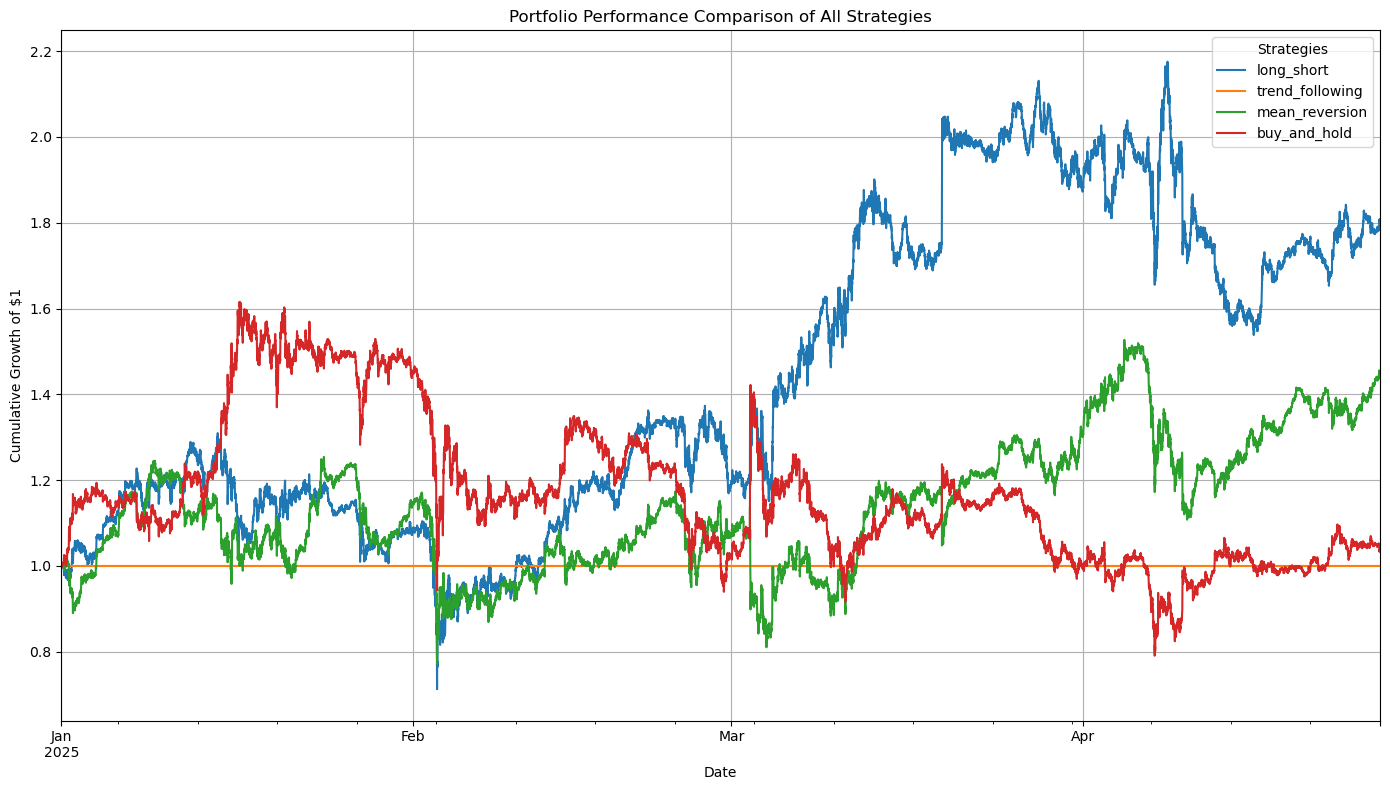


--- Backtest Summary ---
Final portfolio value for each strategy (starting with $1):
long_short         1.81
trend_following    1.00
mean_reversion     1.45
buy_and_hold       1.04
Name: 2025-04-27 03:00:00+00:00, dtype: float64


In [22]:
# This code assumes the previous two scripts have been combined and run.
# You should have the following variables in your environment:
# - df_featured: The full DataFrame with features.
# - X_test: The test features.
# - probs: The prediction probabilities from `best_clf.predict_proba(X_test)[:,1]`
# - All the functions from the second script (e.g., calculate_portfolio_return).

# 1. DEFINE YOUR STRATEGIES AND PORTFOLIO
# ----------------------------------------------------------------
# A list of all strategies we want to backtest and compare.
strategies_to_run = ['long_short', 'trend_following', 'mean_reversion', 'buy_and_hold']

# Define the portfolio weights. Since we only used BTCUSDT, it gets 100% of the allocation.
# The keys here MUST match the coin names used in your data.
portfolio_weights = {
    'XRPUSDT': 1.0
    # If you had more assets, e.g., 'ETHUSDT': 0.5, they would go here.
}

# 2. PREPARE THE DATA AND PREDICTION DICTIONARIES
# ----------------------------------------------------------------
# The function expects dictionaries where keys are the coin names.

# Create the `all_coin_data` dictionary. It holds the price data for the test period.
test_price_data = df_featured.loc[X_test.index]
all_coin_data_dict = {'XRPUSDT': test_price_data}

# Create the `all_coin_predictions` dictionary.
# This is required for 'long_short' and 'trend_following' strategies.
# The predictions (probabilities in this case) need to be in a pandas Series
# with the same index as the test data.
prediction_series = pd.Series(probs, index=X_test.index)
all_coin_predictions_dict = {'XRPUSDT': prediction_series}


# 3. EXECUTE THE BACKTEST FOR ALL STRATEGIES
# ----------------------------------------------------------------
print("\n\n--- Running Backtests for All Strategies ---")

# Create a DataFrame to hold the returns for each strategy
all_portfolio_returns = pd.DataFrame(index=X_test.index)

for strategy_name in strategies_to_run:
    print(f"  - Running backtest for: '{strategy_name}'")
    
    # Determine if the current strategy needs prediction inputs
    predictions_input = None
    if strategy_name in ['long_short', 'trend_following']:
        predictions_input = all_coin_predictions_dict
        
    # Call the main function with the prepared inputs
    portfolio_returns = calculate_portfolio_return(
        strategy_name=strategy_name,
        weights=portfolio_weights,
        all_coin_data=all_coin_data_dict,
        all_coin_predictions=predictions_input
    )
    
    # Store the results in our DataFrame
    all_portfolio_returns[strategy_name] = portfolio_returns

# 4. ANALYZE AND VISUALIZE THE RESULTS
# ----------------------------------------------------------------
# Calculate the cumulative returns to see the performance over time
cumulative_strategy_returns = (1 + all_portfolio_returns).cumprod()

# Plot the equity curves for all strategies on one chart
plt.figure(figsize=(14, 8))
cumulative_strategy_returns.plot(ax=plt.gca()) # Use ax=plt.gca() to plot on the same axes
plt.title("Portfolio Performance Comparison of All Strategies")
plt.xlabel("Date")
plt.ylabel("Cumulative Growth of $1")
plt.legend(title='Strategies')
plt.grid(True)
plt.tight_layout()
plt.savefig("all_strategies_performance.pdf")
plt.show()

print("\n--- Backtest Summary ---")
print("Final portfolio value for each strategy (starting with $1):")
print(cumulative_strategy_returns.iloc[-1].round(2))


An unexpected error occurred: name 'pprint' is not defined


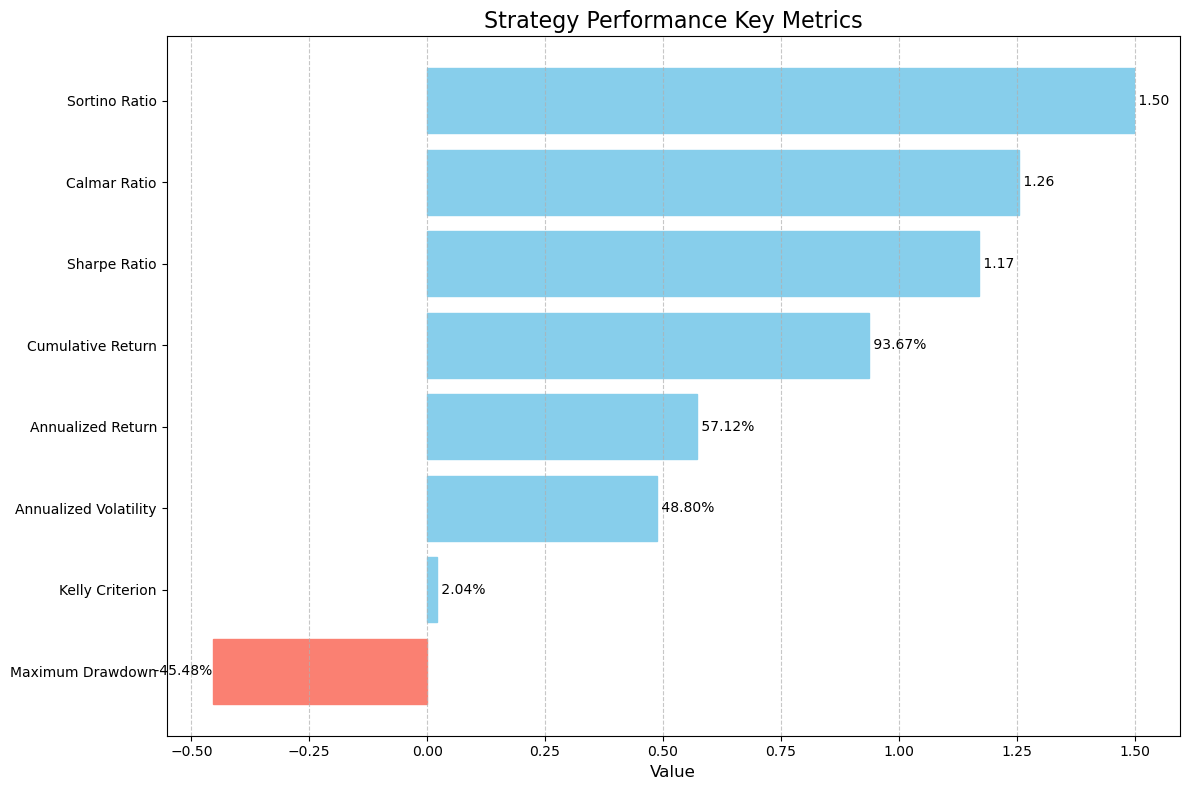

In [10]:
import pandas as pd
import numpy as np

# --- Module 1: Configuration ---
CONFIG = {
    'risk_free_rate': 0.0
}

# --- Module 2: Performance Metrics Calculation ---
def calculate_performance_metrics(returns_series: pd.Series, freq: str = '1H') -> dict:
    """
    Calculates a dictionary of performance metrics based on a series of returns,
    using true geometric compounding for cumulative & annualized returns.

    Args:
        returns_series (pd.Series): periodic (e.g. hourly/daily) simple returns R_t.
        freq (str): data frequency for annualization ('1H','4H','1D', etc).

    Returns:
        dict: KPI metrics including Cumulative Return, CAGR, volatility, ratios, etc.
    """
    # handle empty series
    if returns_series.empty:
        return {
            'Cumulative Return':      0.0,
            'Annualized Return':      0.0,
            'Annualized Volatility':  0.0,
            'Sharpe Ratio':           0.0,
            'Sortino Ratio':          0.0,
            'Maximum Drawdown':       0.0,
            'Calmar Ratio':           0.0,
            'Kelly Criterion':        0.0
        }

    # --- determine periods per year ---
    f = freq.upper()
    if 'H' in f:
        periods_per_year = 24 * 365 / int(f.replace('H',''))
    elif 'D' in f:
        periods_per_year = 252
    else:
        periods_per_year = 24 * 365

    # number of observations
    n_periods = returns_series.shape[0]

    # --- Cumulative Return (geometric) ---
    cumulative_return = (1 + returns_series).prod() - 1

    # --- Annualized Return (CAGR) ---
    # (1 + total_return)^(periods_per_year / n_periods) - 1
    total_return = 1 + cumulative_return
    annualized_return = total_return ** (periods_per_year / n_periods) - 1

    # --- Annualized Volatility ---
    annualized_volatility = returns_series.std(ddof=1) * np.sqrt(periods_per_year)

    # --- Sharpe Ratio (using CAGR) ---
    excess_return = annualized_return - CONFIG['risk_free_rate']
    sharpe_ratio = excess_return / annualized_volatility if annualized_volatility != 0 else 0.0

    # --- Sortino Ratio ---
    downside = returns_series[returns_series < 0]
    downside_dev = (
        downside.std(ddof=1) * np.sqrt(periods_per_year)
        if not downside.empty else 0.0
    )
    sortino_ratio = excess_return / downside_dev if downside_dev != 0 else 0.0

    # --- Equity curve & Max Drawdown ---
    equity_curve = (1 + returns_series).cumprod()
    running_max   = equity_curve.cummax()
    drawdown      = (equity_curve - running_max) / running_max
    max_drawdown  = drawdown.min()

    # --- Calmar Ratio ---
    calmar_ratio = (
        annualized_return / abs(max_drawdown)
        if max_drawdown != 0 else 0.0
    )

    # --- Kelly Criterion ---
    traded = returns_series[returns_series != 0]
    if not traded.empty:
        wins   = traded[traded > 0]
        losses = traded[traded < 0]
        W = len(wins) / len(traded)
        avg_win  = wins.mean() if len(wins)  else 0.0
        avg_loss = losses.mean() if len(losses) else 0.0
        R = avg_win / abs(avg_loss) if avg_loss != 0 else np.inf
        kelly = W - (1 - W) / R if (R > 0 and R != np.inf) else 0.0
    else:
        kelly = 0.0

    return {
        'Cumulative Return':      cumulative_return,
        'Annualized Return':      annualized_return,
        'Annualized Volatility':  annualized_volatility,
        'Sharpe Ratio':           sharpe_ratio,
        'Sortino Ratio':          sortino_ratio,
        'Maximum Drawdown':       max_drawdown,
        'Calmar Ratio':           calmar_ratio,
        'Kelly Criterion':        kelly
    }
     

try:
 
    
    # IMPORTANT: Use the calculated strategy returns as input
    strategy_returns_series = pnl_df['strat_return'].dropna()
    
    # Call the performance metrics function with the correct frequency
    performance_kpis = calculate_performance_metrics(strategy_returns_series, freq='10T')
    
    # Print the results
    pprint.pprint(performance_kpis)
    
    # 7. Plotting Cumulative P&L
    pnl_df['cum_bh'] = (1 + pnl_df['bh_return']).cumprod()
    pnl_df['cum_strat'] = (1 + pnl_df['strat_return']).cumprod()


except FileNotFoundError as e:
    print(f"\nERROR: Could not find the data file. Please ensure 'OHLCV_ffill.parquet' is accessible.")
    print(f"Details: {e}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")
    
# 2. Convert the dictionary to a pandas Series for easy plotting and sorting
kpi_series = pd.Series(performance_kpis).sort_values(ascending=True)

# 3. Create the horizontal bar chart
plt.figure(figsize=(12, 8))
bars = plt.barh(kpi_series.index, kpi_series.values)

# --- Styling the Plot ---
plt.title('Strategy Performance Key Metrics', fontsize=16)
plt.xlabel('Value', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Color bars based on whether the value is positive or negative
for bar in bars:
    if bar.get_width() < 0:
        bar.set_color('salmon') # Negative values are red
    else:
        bar.set_color('skyblue') # Positive values are blue

# Add the exact value labels to the end of each bar
for index, value in enumerate(kpi_series):
    # Determine if the metric should be formatted as a percentage or a decimal
    is_percentage = kpi_series.index[index] in [
        'Cumulative Return', 'Annualized Return', 
        'Annualized Volatility', 'Maximum Drawdown', 'Kelly Criterion'
    ]
    
    # Format the label text accordingly
    label_text = f'{value:.2%}' if is_percentage else f'{value:.2f}'
    
    # Position the text label
    plt.text(
        x=value, 
        y=index, 
        s=f' {label_text}', 
        va='center', 
        ha='left' if value >= 0 else 'right' # Adjust horizontal alignment for negative bars
    )

# --- Display the Plot ---
plt.tight_layout()
plt.show()
     



--- Running Backtests for All Strategies ---
  - Running backtest for: 'long_short'
  - Running backtest for: 'trend_following'
  - Running backtest for: 'mean_reversion'
  - Running backtest for: 'buy_and_hold'


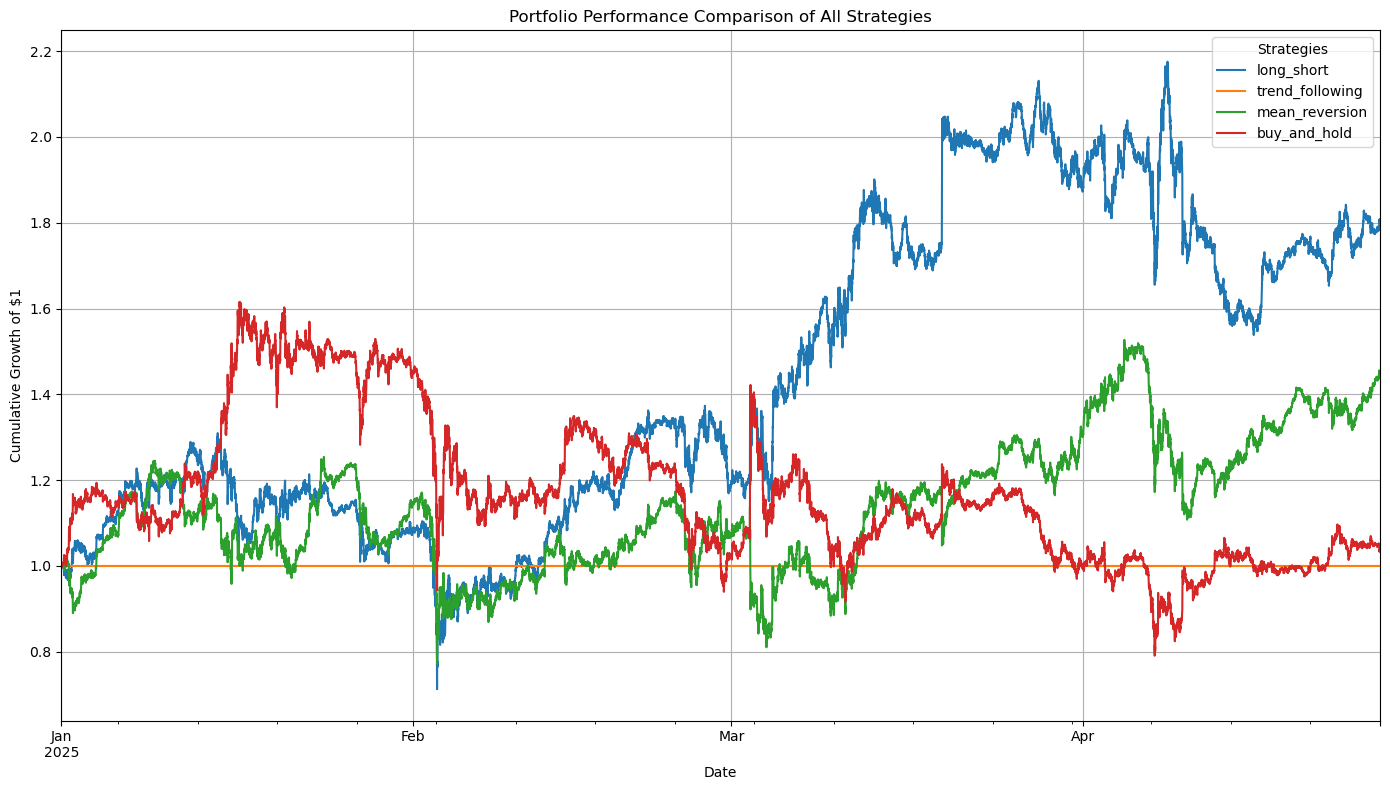


--- Backtest Summary ---
Final portfolio value for each strategy (starting with $1):
long_short         1.81
trend_following    1.00
mean_reversion     1.45
buy_and_hold       1.04
Name: 2025-04-27 03:00:00+00:00, dtype: float64


In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

CONFIG = {
    'initial_capital': 10000.0,
    'commission_rate': 0.0000,      # 0.1% trading fee 0.001
    'slippage_factor': 0,       # 0.05% slippage 0.0005
    'data_frequency': '10min',      # Can be '1H', '4H', '1D', etc.
    'risk_free_rate': 0.0,
    'strategy_params': {
        'long_short': {
            'buy_threshold': 0.5,
            'sell_threshold': 0.5
        },
        'trend_following': {
            'sma_window': 200      # The lookback period for the long-term SMA that defines the trend. A common value is 50, 100, or 200.
        },
        'mean_reversion': {
            'bb_window': 20,       # Lookback window for Bollinger Bands
            'bb_std_dev': 2.0      # Number of standard deviations
        }
    }
}



# --- Strategy Signal Generation ---
# --- 1. Mean Reversion Strategy (with Bollinger Bands/ No need for prediction) ---
def generate_mean_reversion_positions(data):
    """
    Generates positions for a Mean Reversion strategy using Bollinger Bands®.

    This strategy operates independently of a prediction model. It sells when
    the price touches the upper band and buys when it touches the lower band,
    assuming the price will revert to the mean.

    Args:
        data (pd.DataFrame): DataFrame with at least a 'close' column.
    Returns:
        pd.Series: A Series of trading positions.
    """
    window = CONFIG['strategy_params']['mean_reversion']['bb_window']
    num_std_dev = CONFIG['strategy_params']['mean_reversion']['bb_std_dev']
    # 1. Calculate the three Bollinger Bands®.
    middle_band = data['close'].rolling(window=window).mean()      # Middle Band: A simple moving average.
    std_dev = data['close'].rolling(window=window).std()
    upper_band = middle_band + (std_dev * num_std_dev)
    lower_band = middle_band - (std_dev * num_std_dev)

    # 2. Initialize positions with zeros.
    positions = pd.Series(index=data.index, data=0, name='position')
    
    # 3. Generate signals based on price crossing the bands.
    # Note: We compare today's price with yesterday's band to avoid lookahead bias.
    # Go Long (+1) if the price crosses BELOW the lower band.
    positions[data['close'] < lower_band] = 1
    # Go Short (-1) if the price crosses ABOVE the upper band.
    positions[data['close'] > upper_band] = -1

    # 4. Generate exit signals: Close the position when the price crosses the middle band.
    # If we are long and price goes above middle, or if we are short and price goes below, exit.
    # To implement this simply, we can use a forward-fill approach.
    # However, a simpler model for backtesting is to hold for a fixed number of periods
    # or until the price crosses the middle band. For simplicity here, we will hold
    # the position until an opposing signal is generated. A more complex exit logic
    # would involve tracking the state (e.g., are we currently in a long trade?).
    # Let's refine the exit logic for clarity:

    # Create a consolidated signal series (1 for buy, -1 for sell, 0 for hold)
    signals = pd.Series(index=data.index, data=0, name='signal')
    signals[data['close'] < lower_band] = 1       # Buy signal
    signals[data['close'] > upper_band] = -1      # Sell signal
    
    # Forward-fill the signals to hold positions until a new signal appears.
    # For example, a +1 signal will be carried forward until a -1 or 0 signal appears.
    positions = signals.replace(to_replace=0, method='ffill').fillna(0)

    return positions

# --- 2. Buy and Hold Strategy (No need for prediction) ---
def generate_buy_and_hold_positions(data):
    """
    Generates positions for a simple Buy and Hold strategy.

    This strategy enters a long position (+1) at the very beginning
    and holds it until the very end. It's used as a benchmark to
    measure the performance of more active strategies.

    Args:
        data (pd.DataFrame): DataFrame with at least a 'close' column.

    Returns:
        pd.Series: A Series of positions (+1 for all periods).
    """
    # Create a new series named 'positions' with the same index as our data.
    # The value is 1 for every single time period.
    positions = pd.Series(index=data.index, data=1, name='position')
    
    return positions

# --- 3. Long-short strategy ---
def generate_long_short_positions(predictions):
    """
    Generates positions directly from the model's prediction signals.

    This strategy acts as a pure test of the model's accuracy.
    A +1 prediction becomes a long position, a 0 prediction becomes a short position.

    Args:
        predictions (pd.Series): A Series of prediction signals (+1, -1, or 0) from forecasting model, or the Series of pred_proba
    Returns:
        pd.Series: A Series of trading positions.
    """
    positions = pd.Series(index=predictions.index, data=0, name='position')
    long_condition = predictions > CONFIG['strategy_params']['long_short']['buy_threshold']
    positions[long_condition] = 1
    short_condition = (1 - predictions) > CONFIG['strategy_params']['long_short']['sell_threshold']
    positions[short_condition] = -1
    return positions

# --- 4. trend_following_overlay ---
def generate_trend_following_positions(data, predictions):
    """
    Generates positions by filtering primary signals with a long-term trend.

    This strategy only allows trades that are aligned with the overall market
    direction, which is determined by a Simple Moving Average (SMA). It's
    designed to prevent taking short-term trades against a strong trend.

    Args:
        data (pd.DataFrame): DataFrame with at least a 'close' column.
        predictions (pd.Series): The primary trading signals (+1, -1, 0) from
                                 another function (e.g., generate_positions_with_threshold).
    Returns:
        pd.Series: A Series of filtered trading positions (+1, -1, or 0).
    """
    # --- Step 1: Define the Long-Term Trend ---
    # We calculate the Simple Moving Average (SMA) over a long window. This 
    # represents the average price over a significant period and acts as our
    # indicator of the overall market trend.
    long_window = CONFIG['strategy_params']['trend_following']['sma_window']
    long_term_trend = data['close'].rolling(window=long_window).mean()
    positions = pd.Series(index=data.index, data=0, name='position')

    # --- Step 2: Apply the "Go Long" Rule ---
    # We set the position to +1 (Long) only where BOTH of our conditions are met:
    # a) The primary prediction signal is +1 (our model wants to go long).
    # b) The current closing price is above the long-term trend line,
    #    confirming the market is in a general uptrend.
    long_condition = (predictions == 1) & (data['close'] > long_term_trend)
    positions[long_condition] = 1

    # --- Step 3: Apply the "Go Short" Rule ---
    # We set the position to -1 (Short) only where BOTH of our conditions are met:
    # a) The primary prediction signal is -1 (our model wants to go short).
    # b) The current closing price is below the long-term trend line,
    #    confirming the market is in a general downtrend.
    short_condition = (predictions == -1) & (data['close'] < long_term_trend)
    positions[short_condition] = -1

    return positions



# --- Vectorized Backtesting Engine ---
def run_vectorized_backtest(price_data: pd.DataFrame, positions: pd.Series) -> pd.Series:
    """
    Runs a vectorized backtest on a set of price data and position signals.

    This function simulates the process of trading a strategy over historical
    data to see how it would have performed, including realistic costs.

    Args:
        price_data (pd.DataFrame): DataFrame with 'Open', 'High', 'Low', 'Close' columns.
        positions (pd.Series): Series with your strategy's target positions
                               (1 for long, -1 for short, 0 for flat).

    Returns:
        pd.Series: A Series representing the daily or hourly net returns of the strategy.
    """

    asset_returns = price_data['open'].pct_change().shift(-1)
    lagged_positions = positions.shift(1).fillna(0)
    strategy_gross_returns = asset_returns * lagged_positions

    # --- model Trading Costs ---
    # trading cost
    trades = lagged_positions.diff().fillna(0).abs()
    commission_costs = trades * CONFIG['commission_rate']

    # Model "slippage" - the hidden cost of a fast market.
    # When you place an order, the price might move slightly against you before
    # the trade is actually executed. This is slippage.
    # We model this as a small penalty that is larger when the market is more
    # volatile (i.e., when 'asset_returns' is large).
    # This is an *estimated* cost to make the backtest more conservative and realistic.
    slippage_costs = trades * asset_returns.abs() * CONFIG['slippage_factor']


    total_costs = commission_costs + slippage_costs
    strategy_net_returns = strategy_gross_returns - total_costs
    return strategy_net_returns.fillna(0)


def generate_strategy_positions(strategy_name, data, predictions=None):
    """
    Dispatcher to generate positions based on the strategy name.
    """
    if strategy_name == 'mean_reversion':
        return generate_mean_reversion_positions(data)
    elif strategy_name == 'buy_and_hold':
        return generate_buy_and_hold_positions(data)
    elif strategy_name == 'long_short':
        if predictions is None:
            raise ValueError("Long-short strategy requires predictions.")
        return generate_long_short_positions(predictions)
    elif strategy_name == 'trend_following':
        if predictions is None:
            raise ValueError("Trend-following strategy requires predictions.")
        return generate_trend_following_positions(data, predictions)
    else:
        raise ValueError(f"Unknown strategy: {strategy_name}")


def calculate_portfolio_return(strategy_name, weights, all_coin_data, all_coin_predictions=None):
    """
    Calculates the returns of a portfolio of assets, given a trading strategy and asset weights.

    Args:
        strategy_name (str): The name of the strategy to use.
        weights (dict): A dictionary with coin names as keys and their portfolio weights as values.
        all_coin_data (dict): A dictionary of pandas DataFrames, one for each coin, with price data.
        all_coin_predictions (dict, optional): A dictionary of pandas Series, one for each coin,
                                                with prediction signals. Required for some strategies.

    Returns:
        pd.Series: A Series representing the daily net returns of the portfolio.
    """
    all_weighted_returns = {}
    
    for coin, weight in weights.items():
        if coin not in all_coin_data.keys():
            print(f"Warning: Price data for {coin} not found. Skipping.")
            continue

        price_data = all_coin_data[coin]
        predictions = None
        if all_coin_predictions and coin in all_coin_predictions:
            predictions = all_coin_predictions[coin]

        positions = generate_strategy_positions(strategy_name, price_data, predictions)
        net_returns = run_vectorized_backtest(price_data, positions)
        all_weighted_returns[coin] = net_returns * weight

    if not all_weighted_returns:
        return pd.Series(dtype=np.float64)

    portfolio_returns_df = pd.DataFrame(all_weighted_returns)
    portfolio_return = portfolio_returns_df.sum(axis=1, min_count=0).fillna(0)

    return portfolio_return


# This code assumes the previous two scripts have been combined and run.
# You should have the following variables in your environment:
# - df_featured: The full DataFrame with features.
# - X_test: The test features.
# - probs: The prediction probabilities from `best_clf.predict_proba(X_test)[:,1]`
# - All the functions from the second script (e.g., calculate_portfolio_return).

# 1. DEFINE YOUR STRATEGIES AND PORTFOLIO
# ----------------------------------------------------------------
# A list of all strategies we want to backtest and compare.
strategies_to_run = ['long_short', 'trend_following', 'mean_reversion', 'buy_and_hold']

# Define the portfolio weights. Since we only used BTCUSDT, it gets 100% of the allocation.
# The keys here MUST match the coin names used in your data.
portfolio_weights = {
    'XRPUSDT': 1.0
    # If you had more assets, e.g., 'ETHUSDT': 0.5, they would go here.
}

# 2. PREPARE THE DATA AND PREDICTION DICTIONARIES
# ----------------------------------------------------------------
# The function expects dictionaries where keys are the coin names.

# Create the `all_coin_data` dictionary. It holds the price data for the test period.
test_price_data = df_featured.loc[X_test.index]
all_coin_data_dict = {'XRPUSDT': test_price_data}

# Create the `all_coin_predictions` dictionary.
# This is required for 'long_short' and 'trend_following' strategies.
# The predictions (probabilities in this case) need to be in a pandas Series
# with the same index as the test data.
prediction_series = pd.Series(probs, index=X_test.index)
all_coin_predictions_dict = {'XRPUSDT': prediction_series}


# 3. EXECUTE THE BACKTEST FOR ALL STRATEGIES
# ----------------------------------------------------------------
print("\n\n--- Running Backtests for All Strategies ---")

# Create a DataFrame to hold the returns for each strategy
all_portfolio_returns = pd.DataFrame(index=X_test.index)

for strategy_name in strategies_to_run:
    print(f"  - Running backtest for: '{strategy_name}'")
    
    # Determine if the current strategy needs prediction inputs
    predictions_input = None
    if strategy_name in ['long_short', 'trend_following']:
        predictions_input = all_coin_predictions_dict
        
    # Call the main function with the prepared inputs
    portfolio_returns = calculate_portfolio_return(
        strategy_name=strategy_name,
        weights=portfolio_weights,
        all_coin_data=all_coin_data_dict,
        all_coin_predictions=predictions_input
    )
    
    # Store the results in our DataFrame
    all_portfolio_returns[strategy_name] = portfolio_returns

# 4. ANALYZE AND VISUALIZE THE RESULTS
# ----------------------------------------------------------------
# Calculate the cumulative returns to see the performance over time
cumulative_strategy_returns = (1 + all_portfolio_returns).cumprod()

# Plot the equity curves for all strategies on one chart
plt.figure(figsize=(14, 8))
cumulative_strategy_returns.plot(ax=plt.gca()) # Use ax=plt.gca() to plot on the same axes
plt.title("Portfolio Performance Comparison of All Strategies")
plt.xlabel("Date")
plt.ylabel("Cumulative Growth of $1")
plt.legend(title='Strategies')
plt.grid(True)
plt.tight_layout()
plt.savefig("all_strategies_performance.pdf")
plt.show()

print("\n--- Backtest Summary ---")
print("Final portfolio value for each strategy (starting with $1):")
print(cumulative_strategy_returns.iloc[-1].round(2))

An unexpected error occurred: name 'pprint' is not defined


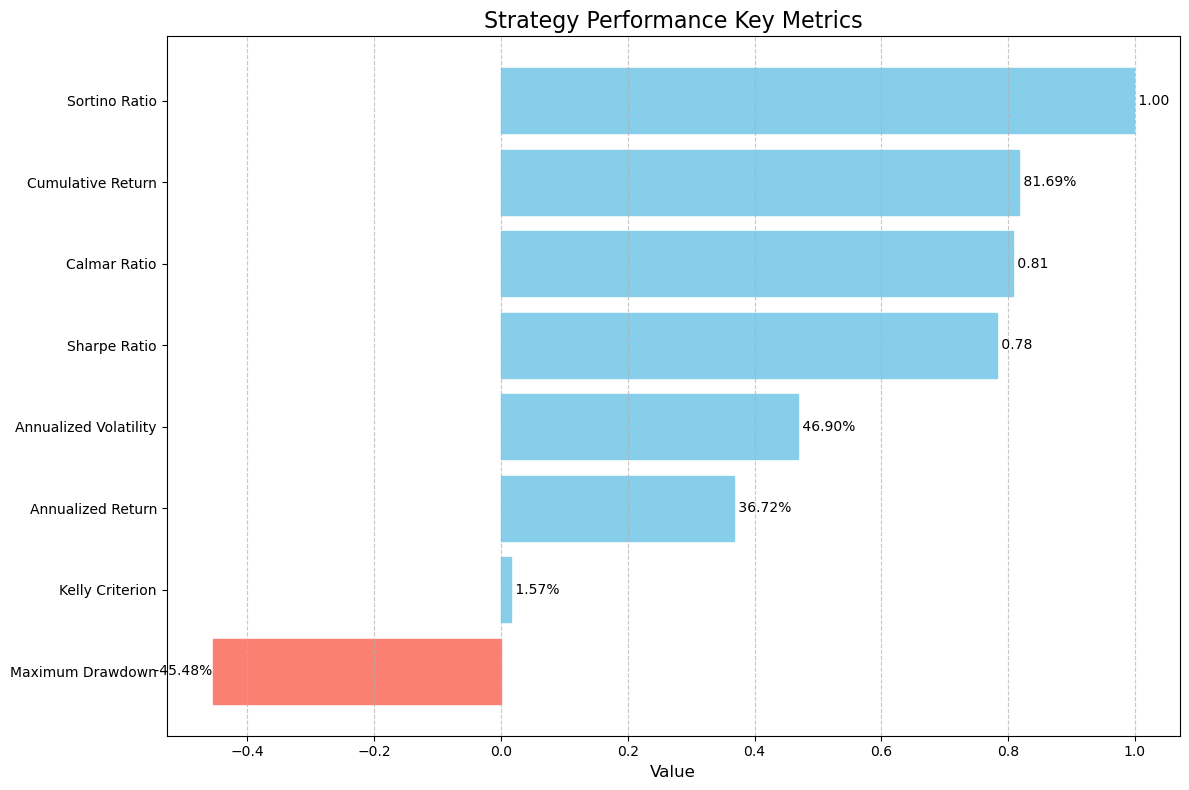

In [25]:
import pandas as pd
import numpy as np

# --- Module 1: Configuration ---
CONFIG = {
    'risk_free_rate': 0.0
}

# --- Module 2: Performance Metrics Calculation ---
def calculate_performance_metrics(returns_series: pd.Series, freq: str = '1H') -> dict:
    """
    Calculates a dictionary of performance metrics based on a series of returns,
    using true geometric compounding for cumulative & annualized returns.

    Args:
        returns_series (pd.Series): periodic (e.g. hourly/daily) simple returns R_t.
        freq (str): data frequency for annualization ('1H','4H','1D', etc).

    Returns:
        dict: KPI metrics including Cumulative Return, CAGR, volatility, ratios, etc.
    """
    # handle empty series
    if returns_series.empty:
        return {
            'Cumulative Return':      0.0,
            'Annualized Return':      0.0,
            'Annualized Volatility':  0.0,
            'Sharpe Ratio':           0.0,
            'Sortino Ratio':          0.0,
            'Maximum Drawdown':       0.0,
            'Calmar Ratio':           0.0,
            'Kelly Criterion':        0.0
        }

    # --- determine periods per year ---
    f = freq.upper()
    if 'H' in f:
        periods_per_year = 24 * 365 / int(f.replace('H',''))
    elif 'D' in f:
        periods_per_year = 252
    else:
        periods_per_year = 24 * 365

    # number of observations
    n_periods = returns_series.shape[0]

    # --- Cumulative Return (geometric) ---
    cumulative_return = (1 + returns_series).prod() - 1

    # --- Annualized Return (CAGR) ---
    # (1 + total_return)^(periods_per_year / n_periods) - 1
    total_return = 1 + cumulative_return
    annualized_return = total_return ** (periods_per_year / n_periods) - 1

    # --- Annualized Volatility ---
    annualized_volatility = returns_series.std(ddof=1) * np.sqrt(periods_per_year)

    # --- Sharpe Ratio (using CAGR) ---
    excess_return = annualized_return - CONFIG['risk_free_rate']
    sharpe_ratio = excess_return / annualized_volatility if annualized_volatility != 0 else 0.0

    # --- Sortino Ratio ---
    downside = returns_series[returns_series < 0]
    downside_dev = (
        downside.std(ddof=1) * np.sqrt(periods_per_year)
        if not downside.empty else 0.0
    )
    sortino_ratio = excess_return / downside_dev if downside_dev != 0 else 0.0

    # --- Equity curve & Max Drawdown ---
    equity_curve = (1 + returns_series).cumprod()
    running_max   = equity_curve.cummax()
    drawdown      = (equity_curve - running_max) / running_max
    max_drawdown  = drawdown.min()

    # --- Calmar Ratio ---
    calmar_ratio = (
        annualized_return / abs(max_drawdown)
        if max_drawdown != 0 else 0.0
    )

    # --- Kelly Criterion ---
    traded = returns_series[returns_series != 0]
    if not traded.empty:
        wins   = traded[traded > 0]
        losses = traded[traded < 0]
        W = len(wins) / len(traded)
        avg_win  = wins.mean() if len(wins)  else 0.0
        avg_loss = losses.mean() if len(losses) else 0.0
        R = avg_win / abs(avg_loss) if avg_loss != 0 else np.inf
        kelly = W - (1 - W) / R if (R > 0 and R != np.inf) else 0.0
    else:
        kelly = 0.0

    return {
        'Cumulative Return':      cumulative_return,
        'Annualized Return':      annualized_return,
        'Annualized Volatility':  annualized_volatility,
        'Sharpe Ratio':           sharpe_ratio,
        'Sortino Ratio':          sortino_ratio,
        'Maximum Drawdown':       max_drawdown,
        'Calmar Ratio':           calmar_ratio,
        'Kelly Criterion':        kelly
    }
     

try:
 
    
    # IMPORTANT: Use the calculated strategy returns as input
    strategy_returns_series = pnl_df['strat_return'].dropna()
    
    # Call the performance metrics function with the correct frequency
    performance_kpis = calculate_performance_metrics(strategy_returns_series, freq='10T')
    
    # Print the results
    pprint.pprint(performance_kpis)
    
    # 7. Plotting Cumulative P&L
    pnl_df['cum_bh'] = (1 + pnl_df['bh_return']).cumprod()
    pnl_df['cum_strat'] = (1 + pnl_df['strat_return']).cumprod()


except FileNotFoundError as e:
    print(f"\nERROR: Could not find the data file. Please ensure 'OHLCV_ffill.parquet' is accessible.")
    print(f"Details: {e}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")
    
# 2. Convert the dictionary to a pandas Series for easy plotting and sorting
kpi_series = pd.Series(performance_kpis).sort_values(ascending=True)

# 3. Create the horizontal bar chart
plt.figure(figsize=(12, 8))
bars = plt.barh(kpi_series.index, kpi_series.values)

# --- Styling the Plot ---
plt.title('Strategy Performance Key Metrics', fontsize=16)
plt.xlabel('Value', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Color bars based on whether the value is positive or negative
for bar in bars:
    if bar.get_width() < 0:
        bar.set_color('salmon') # Negative values are red
    else:
        bar.set_color('skyblue') # Positive values are blue

# Add the exact value labels to the end of each bar
for index, value in enumerate(kpi_series):
    # Determine if the metric should be formatted as a percentage or a decimal
    is_percentage = kpi_series.index[index] in [
        'Cumulative Return', 'Annualized Return', 
        'Annualized Volatility', 'Maximum Drawdown', 'Kelly Criterion'
    ]
    
    # Format the label text accordingly
    label_text = f'{value:.2%}' if is_percentage else f'{value:.2f}'
    
    # Position the text label
    plt.text(
        x=value, 
        y=index, 
        s=f' {label_text}', 
        va='center', 
        ha='left' if value >= 0 else 'right' # Adjust horizontal alignment for negative bars
    )

# --- Display the Plot ---
plt.tight_layout()
plt.show()



--- Running Backtests for All Strategies ---
  - Running backtest for: 'long_short'
  - Running backtest for: 'trend_following'
  - Running backtest for: 'mean_reversion'
  - Running backtest for: 'buy_and_hold'

--- Saving Long-Short Strategy Curve Data ---
Successfully saved x (Date) and y (Cumulative_Return) to 'long_short_curve_data.csv'


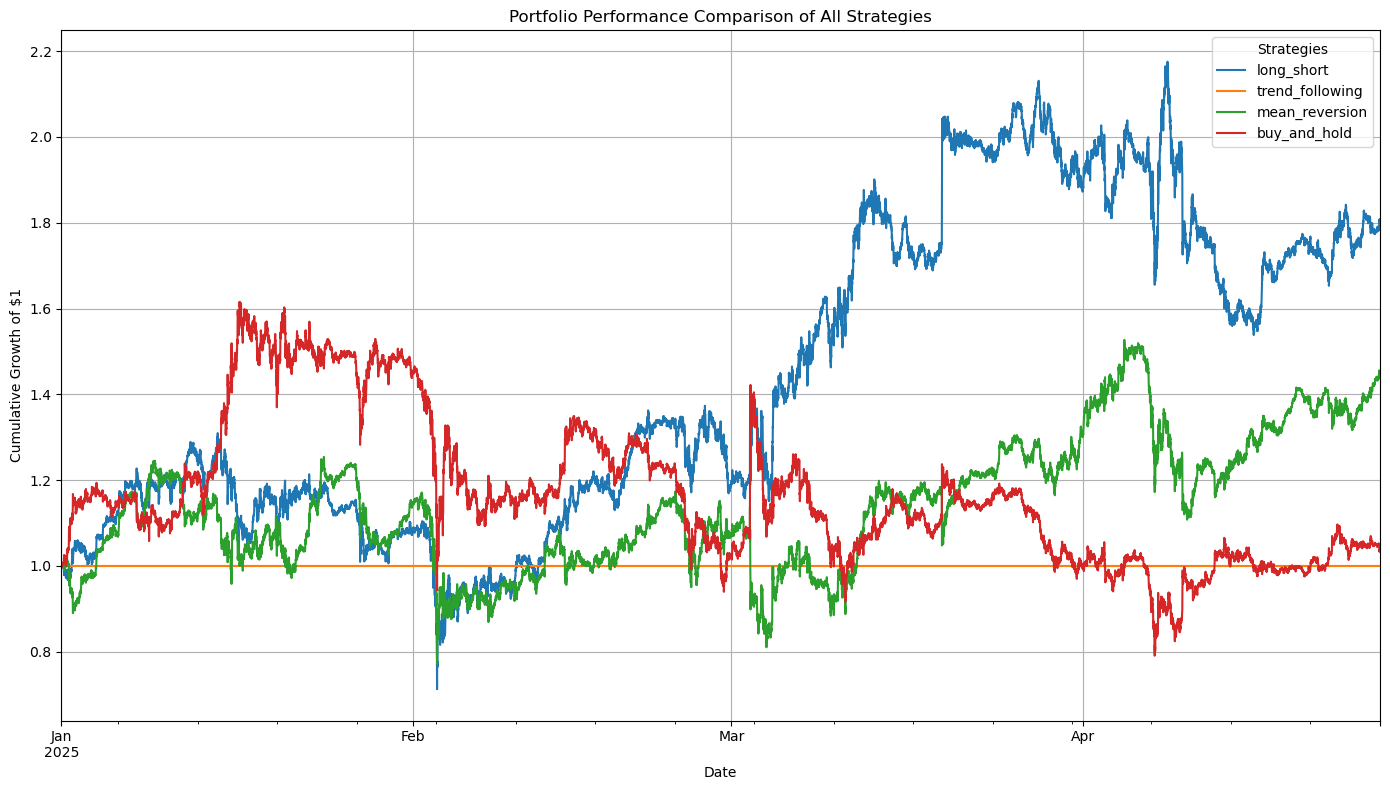


--- Backtest Summary ---
Final portfolio value for each strategy (starting with $1):
long_short         1.81
trend_following    1.00
mean_reversion     1.45
buy_and_hold       1.04
Name: 2025-04-27 03:00:00+00:00, dtype: float64
[LightGBM] [Info] Number of positive: 67095, number of negative: 70162
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008522 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2071
[LightGBM] [Info] Number of data points in the train set: 137257, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.488828 -> initscore=-0.044697
[LightGBM] [Info] Start training from score -0.044697
[LightGBM] [Info] Number of positive: 67094, number of negative: 70163
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.009906 seconds.
You can set `force_col_wise=true` to

[LightGBM] [Info] Number of positive: 67095, number of negative: 70162
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.068945 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2071
[LightGBM] [Info] Number of data points in the train set: 137257, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.488828 -> initscore=-0.044697
[LightGBM] [Info] Start training from score -0.044697
[LightGBM] [Info] Number of positive: 67095, number of negative: 70163
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003747 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2071
[LightGBM] [Info] Number of data points in the train set: 137258, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.488824 -> initscore=-0.044712


In [24]:
# 3. EXECUTE THE BACKTEST FOR ALL STRATEGIES
# ----------------------------------------------------------------
print("\n\n--- Running Backtests for All Strategies ---")

# Create a DataFrame to hold the returns for each strategy
all_portfolio_returns = pd.DataFrame(index=X_test.index)

for strategy_name in strategies_to_run:
    print(f"  - Running backtest for: '{strategy_name}'")
    
    # Determine if the current strategy needs prediction inputs
    predictions_input = None
    if strategy_name in ['long_short', 'trend_following']:
        predictions_input = all_coin_predictions_dict
        
    # Call the main function with the prepared inputs
    portfolio_returns = calculate_portfolio_return(
        strategy_name=strategy_name,
        weights=portfolio_weights,
        all_coin_data=all_coin_data_dict,
        all_coin_predictions=predictions_input
    )
    
    # Store the results in our DataFrame
    all_portfolio_returns[strategy_name] = portfolio_returns

# 4. ANALYZE AND VISUALIZE THE RESULTS
# ----------------------------------------------------------------
# Calculate the cumulative returns to see the performance over time
cumulative_strategy_returns = (1 + all_portfolio_returns).cumprod()


# --- NEW: SAVE THE LONG-SHORT STRATEGY CURVE SEPARATELY ---
# ----------------------------------------------------------------
# Check if the 'long_short' strategy was run
if 'long_short' in cumulative_strategy_returns.columns:
    print("\n--- Saving Long-Short Strategy Curve Data ---")
    
    # Extract the x-values (Date index)
    long_short_x = cumulative_strategy_returns.index
    
    # Extract the y-values (cumulative returns for the long-short strategy)
    long_short_y = cumulative_strategy_returns['long_short']
    
    # To save them separately, you can create a new DataFrame and save it to a CSV file
    long_short_curve_data = pd.DataFrame({
        'Date': long_short_x,
        'Cumulative_Return': long_short_y
    })
    
    # Save the data to a CSV file
    long_short_curve_data.to_csv('long_short_curve_5.csv', index=False)
    
    print("Successfully saved x (Date) and y (Cumulative_Return) to 'long_short_curve_data.csv'")
    
else:
    print("\n'long_short' strategy not found in results. Skipping save.")

# ----------------------------------------------------------------


# Plot the equity curves for all strategies on one chart
plt.figure(figsize=(14, 8))
cumulative_strategy_returns.plot(ax=plt.gca()) # Use ax=plt.gca() to plot on the same axes
plt.title("Portfolio Performance Comparison of All Strategies")
plt.xlabel("Date")
plt.ylabel("Cumulative Growth of $1")
plt.legend(title='Strategies')
plt.grid(True)
plt.tight_layout()
plt.savefig("all_strategies_performance.pdf")
plt.show()

print("\n--- Backtest Summary ---")
print("Final portfolio value for each strategy (starting with $1):")
print(cumulative_strategy_returns.iloc[-1].round(2))